# 04 — Demand Forecasting

Order volume forecasting for staffing/ops decisions: "how many delivery partners do we need on shift tomorrow?" Aggregates to daily grain, engineers lag/calendar features, and forecasts with a time-based (never shuffled) train/test split.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option('display.max_columns', 40)


In [2]:
from forecasting import build_daily_demand, train_forecast_model

train = pd.read_parquet('../data/processed/train_clean.parquet')
daily = build_daily_demand(train)
daily.tail()

,date,orders,pct_festival,pct_bad_weather,dow,is_weekend,lag_1,lag_2,lag_3,lag_7,rolling_mean_3,rolling_mean_7
39,2022-04-02,992,0.032258,0.526210,5,1,1133.0,967.0,1141.0,1166.0,1080.333333,1069.714286
40,2022-04-03,1178,0.004244,0.528014,6,1,992.0,1133.0,967.0,965.0,1030.666667,1044.857143
41,2022-04-04,941,0.032944,0.504782,0,0,1178.0,992.0,1133.0,1139.0,1101.000000,1075.285714
42,2022-04-05,1157,0.004322,0.536733,1,0,941.0,1178.0,992.0,977.0,1037.000000,1047.000000
43,2022-04-06,961,0.038502,0.498439,2,0,1157.0,941.0,1178.0,1141.0,1092.000000,1072.714286


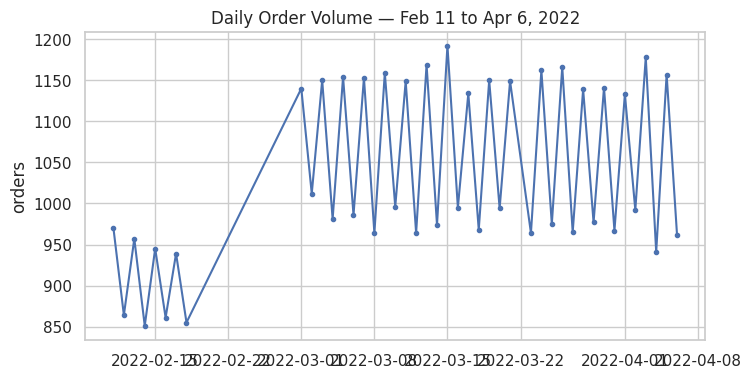

In [3]:
plt.figure(figsize=(8,4))
plt.plot(daily['date'], daily['orders'], marker='o', markersize=3)
plt.title('Daily Order Volume — Feb 11 to Apr 6, 2022')
plt.ylabel('orders')
plt.show()

In [4]:
out = train_forecast_model(daily, models_dir='../models')
print(f"Model MAE: {out['mae']:.1f} orders/day (MAPE {out['mape']*100:.1f}%)")
print(f"Naive same-day-last-week baseline MAE: {out['naive_mae']:.1f} orders/day")

Model MAE: 25.7 orders/day (MAPE 2.5%)
Naive same-day-last-week baseline MAE: 183.0 orders/day


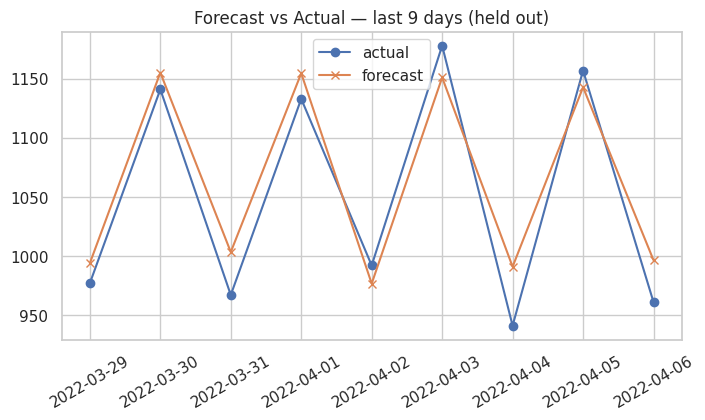

In [5]:
plt.figure(figsize=(8,4))
plt.plot(out['test_dates'], out['y_true'], marker='o', label='actual')
plt.plot(out['test_dates'], out['y_pred'], marker='x', label='forecast')
plt.xticks(rotation=30)
plt.legend()
plt.title('Forecast vs Actual — last 9 days (held out)')
plt.show()

## Result

The gradient-boosted forecast (dow + festival/weather rate + lag-1/2/3/7 + rolling means) beats a same-day-last-week naive baseline by a wide margin on the held-out window. With only ~44 days of history this is a proof of concept — a production version would want a longer history and hourly granularity per city for partner-shift scheduling.